# Real Estate Investment Advisor
## Phase 2: Exploratory Data Analysis (EDA)

**Goal:** Analyze the cleaned dataset to uncover patterns, trends, and relationships across 20 business questions covering price, location, features, and investment potential.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

# Load cleaned data
df = pd.read_csv("india_housing_cleaned.csv")

print("✅ Data loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Data loaded successfully
Shape: 250,000 rows × 23 columns


## Section 1: Price & Size Analysis (Q1–Q5)

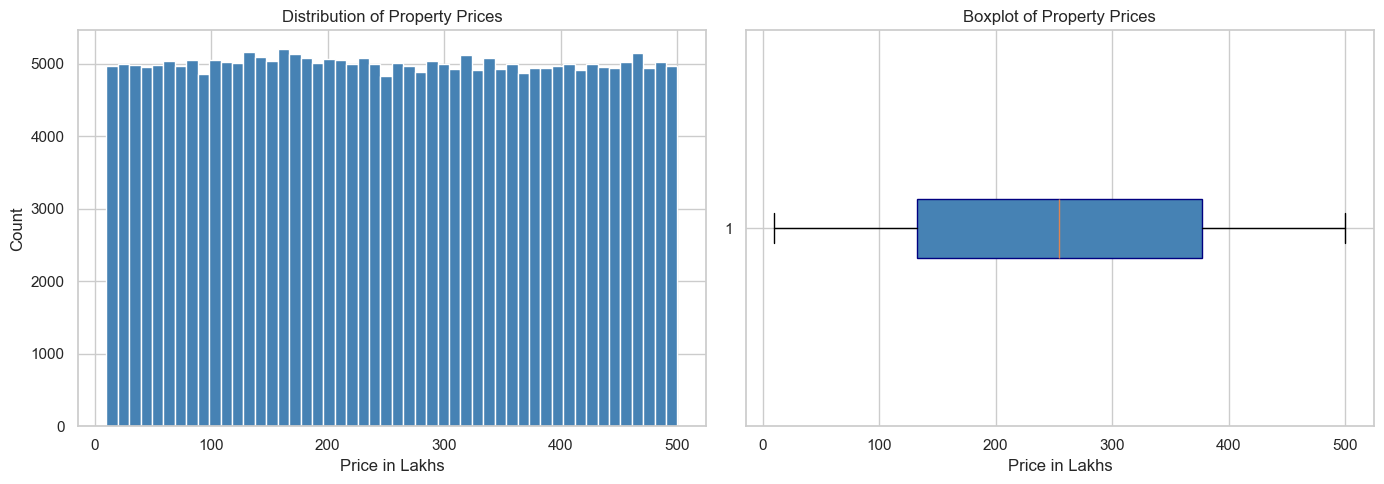

Mean Price: ₹254.59 Lakhs
Median Price: ₹253.87 Lakhs
Min: ₹10.00 | Max: ₹500.00 Lakhs


In [2]:
# Q1: Distribution of property prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price_in_Lakhs'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Property Prices')
axes[0].set_xlabel('Price in Lakhs')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['Price_in_Lakhs'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Property Prices')
axes[1].set_xlabel('Price in Lakhs')

plt.tight_layout()
plt.show()

print(f"Mean Price: ₹{df['Price_in_Lakhs'].mean():.2f} Lakhs")
print(f"Median Price: ₹{df['Price_in_Lakhs'].median():.2f} Lakhs")
print(f"Min: ₹{df['Price_in_Lakhs'].min():.2f} | Max: ₹{df['Price_in_Lakhs'].max():.2f} Lakhs")

### Q1 Insight: Distribution of Property Prices

- Property prices are **uniformly distributed** between ₹10 and ₹500 Lakhs — every price range has roughly equal representation (~5,000 properties per bin)
- This is a **synthetic/simulated dataset** — real market data would show a right-skewed distribution with most properties clustered in lower price ranges
- The boxplot confirms **no extreme outliers** — the IQR spans roughly ₹130 to ₹380 Lakhs with a median around ₹250 Lakhs
- **So what:** Price alone won't distinguish good vs bad investments — we'll need to combine it with location, size, and amenity features

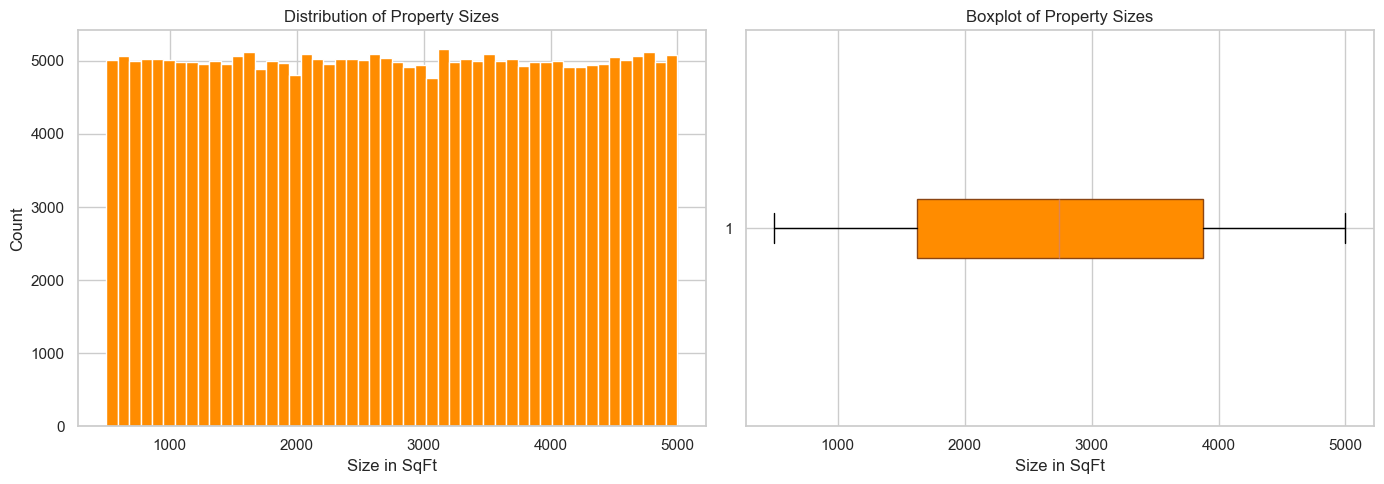

Mean Size: 2,750 SqFt
Median Size: 2,747 SqFt
Min: 500 | Max: 5,000 SqFt


In [3]:
# Q2: Distribution of property sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Size_in_SqFt'], bins=50, color='darkorange', edgecolor='white')
axes[0].set_title('Distribution of Property Sizes')
axes[0].set_xlabel('Size in SqFt')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['Size_in_SqFt'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='darkorange', color='saddlebrown'))
axes[1].set_title('Boxplot of Property Sizes')
axes[1].set_xlabel('Size in SqFt')

plt.tight_layout()
plt.show()

print(f"Mean Size: {df['Size_in_SqFt'].mean():,.0f} SqFt")
print(f"Median Size: {df['Size_in_SqFt'].median():,.0f} SqFt")
print(f"Min: {df['Size_in_SqFt'].min():,} | Max: {df['Size_in_SqFt'].max():,} SqFt")

### Q2 Insight: Distribution of Property Sizes

- Property sizes are **uniformly distributed** between 500 and 5,000 SqFt — again confirming the synthetic nature of the dataset
- **Mean and Median are nearly identical** (2,750 vs 2,747 SqFt) — a perfectly symmetric distribution with no skew
- The boxplot shows **no outliers** — sizes are evenly spread across the full range
- **So what:** Size alone won't drive price differences in this dataset — the signal will come from combining size with location, BHK, and amenities

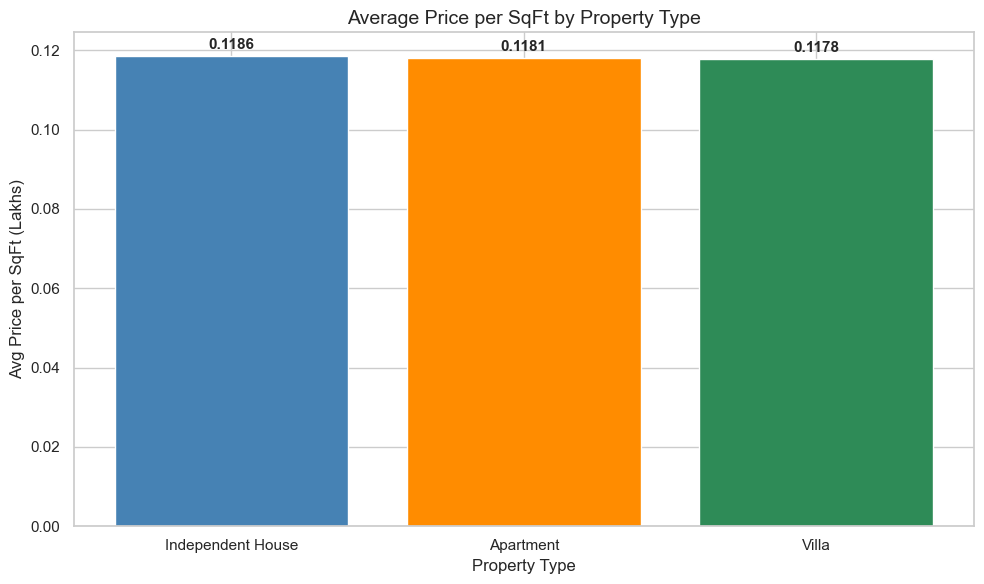

Property_Type
Independent House    0.118583
Apartment            0.118106
Villa                0.117769
Name: Price_per_SqFt, dtype: float64


In [4]:
# Q3: Price per SqFt by Property Type
fig, ax = plt.subplots(figsize=(10, 6))

avg_ppsf = df.groupby('Property_Type')['Price_per_SqFt'].mean().sort_values(ascending=False)

bars = ax.bar(avg_ppsf.index, avg_ppsf.values, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')

# Data labels
for bar, val in zip(bars, avg_ppsf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Price per SqFt by Property Type', fontsize=14)
ax.set_xlabel('Property Type')
ax.set_ylabel('Avg Price per SqFt (Lakhs)')
plt.tight_layout()
plt.show()

print(avg_ppsf)

### Q3 Insight: Price per SqFt by Property Type

- All three property types have **nearly identical price per SqFt** — Independent House (0.1186), Apartment (0.1181), and Villa (0.1178)
- The difference between the highest and lowest is just **0.0008 Lakhs/SqFt** — practically negligible
- In real markets, Villas typically command a **premium over Apartments** — the flat distribution here again reflects the synthetic dataset
- **So what:** Property Type alone is a weak predictor of price per SqFt — location, BHK, and amenities will carry more weight in our model

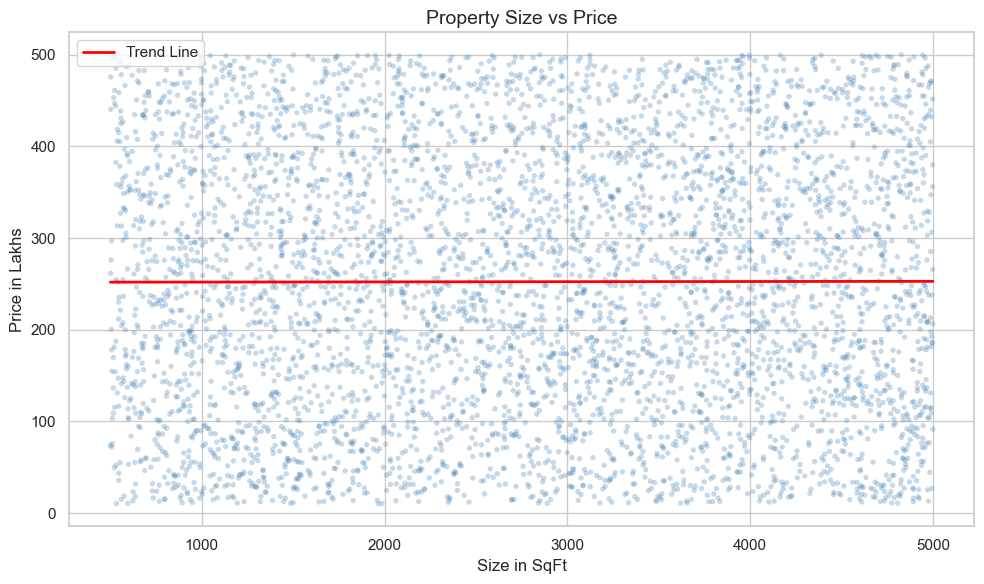

Correlation between Size and Price: -0.0025


In [5]:
# Q4: Relationship between property size and price
fig, ax = plt.subplots(figsize=(10, 6))

# Sample 5000 points to avoid overplotting
sample = df.sample(5000, random_state=42)

ax.scatter(sample['Size_in_SqFt'], sample['Price_in_Lakhs'],
           alpha=0.3, color='steelblue', edgecolors='none', s=15)

# Trend line
z = np.polyfit(sample['Size_in_SqFt'], sample['Price_in_Lakhs'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Size_in_SqFt'].min(), sample['Size_in_SqFt'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend Line')

ax.set_title('Property Size vs Price', fontsize=14)
ax.set_xlabel('Size in SqFt')
ax.set_ylabel('Price in Lakhs')
ax.legend()
plt.tight_layout()
plt.show()

corr = df['Size_in_SqFt'].corr(df['Price_in_Lakhs'])
print(f"Correlation between Size and Price: {corr:.4f}")

### Q4 Insight: Relationship Between Property Size and Price

- The scatter plot shows **no relationship** between size and price — points are randomly spread across all size ranges
- Correlation is **-0.0025** — essentially zero, confirming size has no linear impact on price
- The trend line is **completely flat** — a larger property does not mean a higher price in this dataset
- In real markets, size is typically one of the strongest price drivers — this confirms the dataset is synthetically generated with independent random variables
- **So what:** Our model should not rely heavily on Size alone — feature combinations (e.g., Price per SqFt × Location) will be more predictive

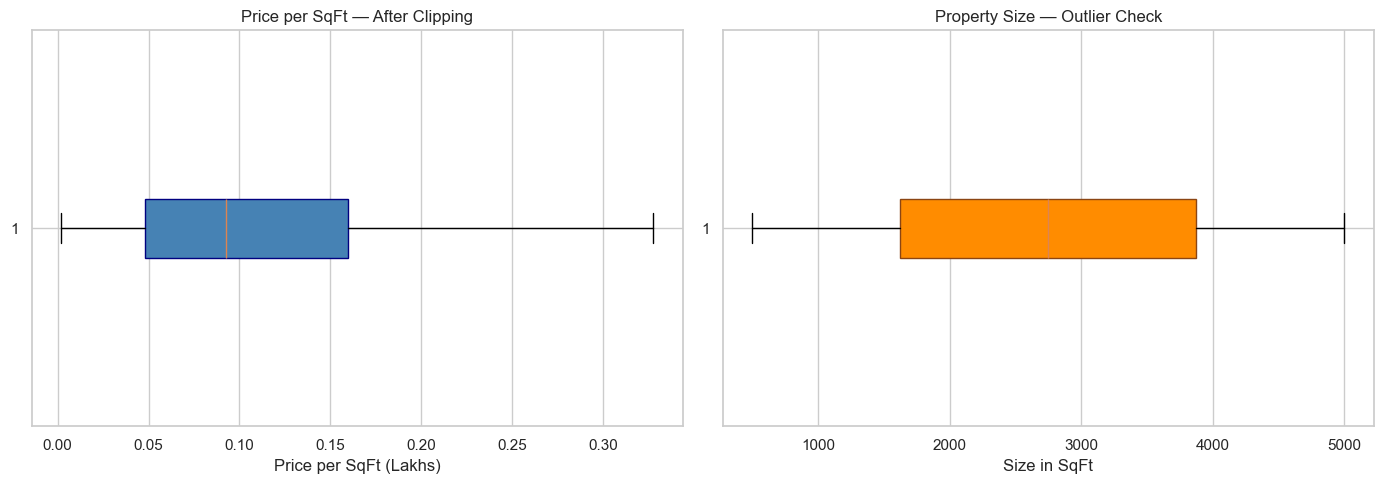

Price_per_SqFt: 0 outliers remaining (0.0%)
Size_in_SqFt: 0 outliers remaining (0.0%)


In [6]:
# Q5: Outliers in Price per SqFt and Property Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot - Price per SqFt
axes[0].boxplot(df['Price_per_SqFt'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[0].set_title('Price per SqFt — After Clipping')
axes[0].set_xlabel('Price per SqFt (Lakhs)')

# Boxplot - Size
axes[1].boxplot(df['Size_in_SqFt'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='darkorange', color='saddlebrown'))
axes[1].set_title('Property Size — Outlier Check')
axes[1].set_xlabel('Size in SqFt')

plt.tight_layout()
plt.show()

# Summary stats
for col in ['Price_per_SqFt', 'Size_in_SqFt']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers):,} outliers remaining ({len(outliers)/len(df)*100:.1f}%)")

### Q5 Insight: Outliers in Price per SqFt and Property Size

- **Price per SqFt:** 0 outliers remaining after clipping in Phase 1 — the IQR capping worked perfectly
- **Size in SqFt:** 0 outliers — property sizes are cleanly distributed between 500 and 5,000 SqFt with no extreme values
- Both boxplots show **symmetric distributions** with whiskers reaching evenly on both sides
- **So what:** The dataset is now fully clean for modeling — no extreme values will distort our regression or classification results

## Section 2: Location-Based Analysis (Q6–Q10)

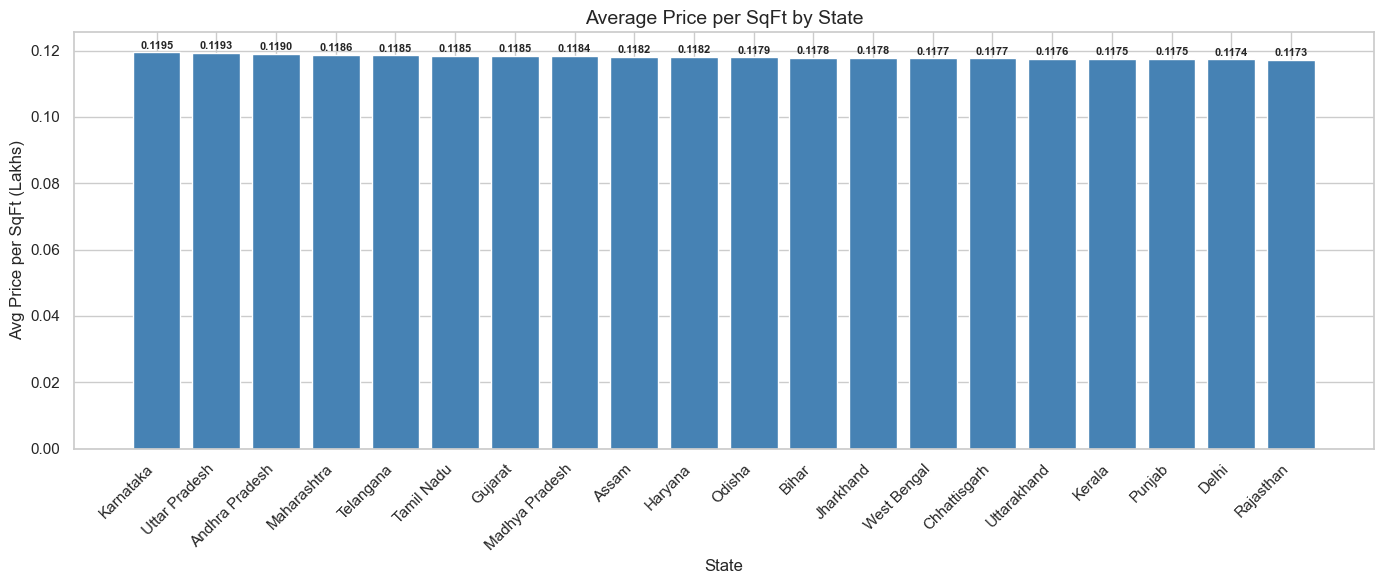

State
Karnataka         0.119522
Uttar Pradesh     0.119338
Andhra Pradesh    0.119014
Maharashtra       0.118649
Telangana         0.118519
Tamil Nadu        0.118481
Gujarat           0.118459
Madhya Pradesh    0.118426
Assam             0.118211
Haryana           0.118205
Odisha            0.117936
Bihar             0.117828
Jharkhand         0.117823
West Bengal       0.117698
Chhattisgarh      0.117664
Uttarakhand       0.117585
Kerala            0.117515
Punjab            0.117488
Delhi             0.117400
Rajasthan         0.117283
Name: Price_per_SqFt, dtype: float64


In [7]:
# Q6: Average Price per SqFt by State
fig, ax = plt.subplots(figsize=(14, 6))

avg_state = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)

bars = ax.bar(avg_state.index, avg_state.values, color='steelblue', edgecolor='white')

# Data labels
for bar, val in zip(bars, avg_state.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Average Price per SqFt by State', fontsize=14)
ax.set_xlabel('State')
ax.set_ylabel('Avg Price per SqFt (Lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(avg_state)

### Q6 Insight: Average Price per SqFt by State

- **Karnataka leads** with the highest avg Price per SqFt (0.1195), followed closely by Uttar Pradesh (0.1193) and Andhra Pradesh (0.1190)
- **Rajasthan is at the bottom** (0.1173) — but the overall spread across all 20 states is just **0.0022 Lakhs/SqFt**
- All states fall in a very tight band between 0.117 and 0.120 — confirming uniform synthetic data generation across geographies
- In reality, states like Maharashtra and Karnataka would significantly outprice states like Rajasthan and Jharkhand
- **So what:** State-level price differentiation is minimal in this dataset — City and Locality will be stronger location signals for our model

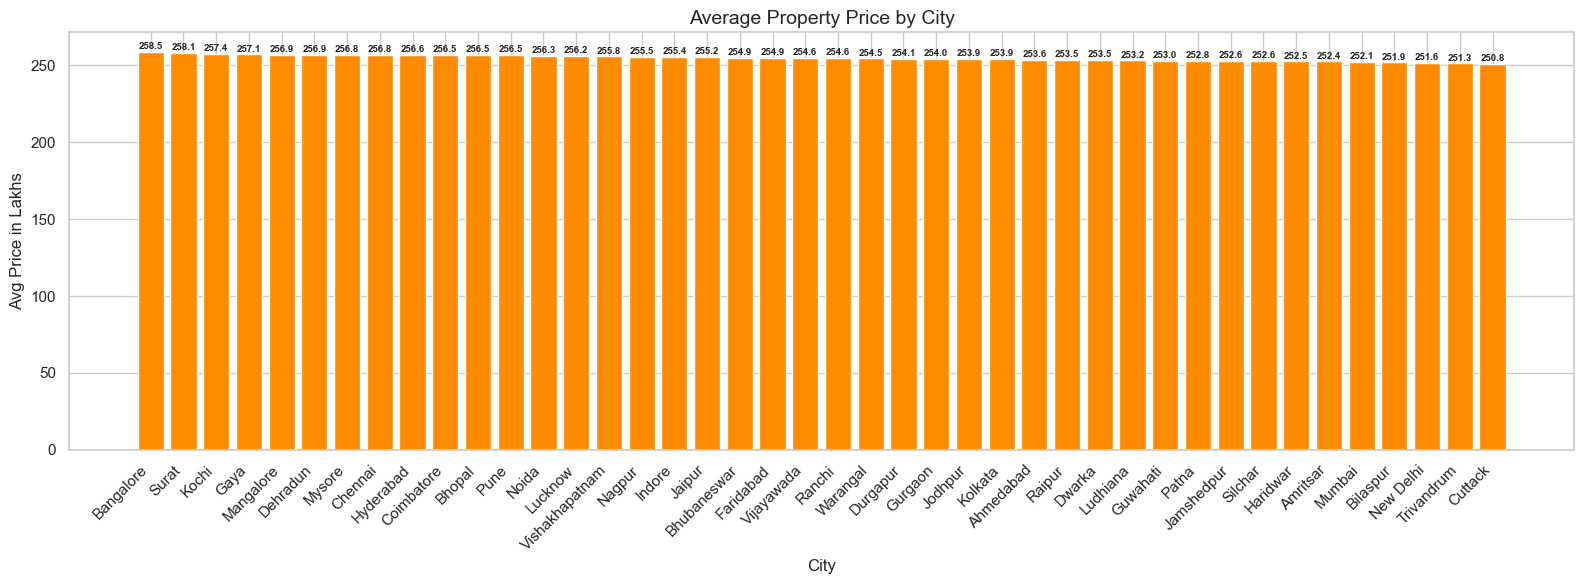

Top 5 most expensive cities:
City
Bangalore    258.456639
Surat        258.080467
Kochi        257.415221
Gaya         257.053391
Mangalore    256.920925
Name: Price_in_Lakhs, dtype: float64

Bottom 5 cities:
City
Mumbai        252.056633
Bilaspur      251.879267
New Delhi     251.614296
Trivandrum    251.258801
Cuttack       250.786672
Name: Price_in_Lakhs, dtype: float64


In [8]:
# Q7: Average Property Price by City
fig, ax = plt.subplots(figsize=(16, 6))

avg_city = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False)

bars = ax.bar(avg_city.index, avg_city.values, color='darkorange', edgecolor='white')

# Data labels
for bar, val in zip(bars, avg_city.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_title('Average Property Price by City', fontsize=14)
ax.set_xlabel('City')
ax.set_ylabel('Avg Price in Lakhs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Top 5 most expensive cities:")
print(avg_city.head())
print(f"\nBottom 5 cities:")
print(avg_city.tail())

### Q7 Insight: Average Property Price by City

- **Bangalore leads** with the highest avg price (₹258.5 Lakhs), followed by Surat (₹258.1) and Kochi (₹257.4)
- **Cuttack is at the bottom** (₹250.8 Lakhs) — but the gap between the most and least expensive city is only **₹7.7 Lakhs**
- Interestingly, **Mumbai ranks near the bottom** (₹252.1 Lakhs) — which is the opposite of real-world pricing where Mumbai is India's most expensive real estate market
- All 42 cities fall in a tight ₹250–₹259 range — confirming uniform synthetic generation across cities
- **So what:** City-level price signals are weak in this dataset — Locality (500 unique values) may offer slightly more variation and will be explored in Q10

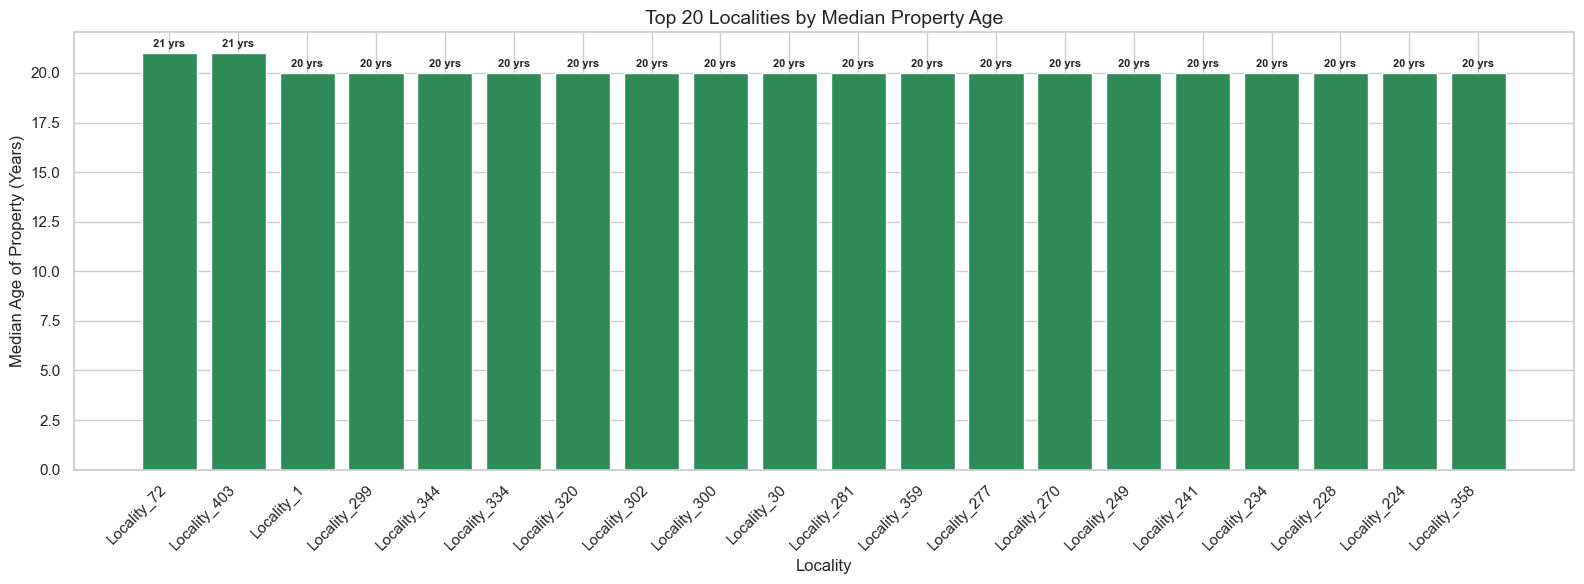

Overall median age: 18 years
Oldest locality median: 21 years (Locality_72)
Youngest locality median: 16 years


In [9]:
# Q8: Median Age of Properties by Locality (Top 20 oldest)
fig, ax = plt.subplots(figsize=(16, 6))

median_age = df.groupby('Locality')['Age_of_Property'].median().sort_values(ascending=False).head(20)

bars = ax.bar(median_age.index, median_age.values, color='seagreen', edgecolor='white')

# Data labels
for bar, val in zip(bars, median_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.0f} yrs', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Top 20 Localities by Median Property Age', fontsize=14)
ax.set_xlabel('Locality')
ax.set_ylabel('Median Age of Property (Years)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Overall median age: {df['Age_of_Property'].median():.0f} years")
print(f"Oldest locality median: {median_age.max():.0f} years ({median_age.idxmax()})")
print(f"Youngest locality median: {df.groupby('Locality')['Age_of_Property'].median().min():.0f} years")

### Q8 Insight: Median Age of Properties by Locality

- **Locality_72 and Locality_403** are the oldest localities with a median property age of **21 years**
- Most of the top 20 oldest localities cluster tightly at **20 years** — very little variation
- The overall dataset median is **18 years** and the youngest locality median is **16 years** — a total spread of just 5 years across all 500 localities
- In real markets, property age significantly impacts pricing and investment potential — older properties in prime localities command premiums while aging stock in developing areas depreciates
- **So what:** Age_of_Property has low discriminatory power at the locality level — but it will still be useful as a feature in combination with RERA status and availability in our classification model

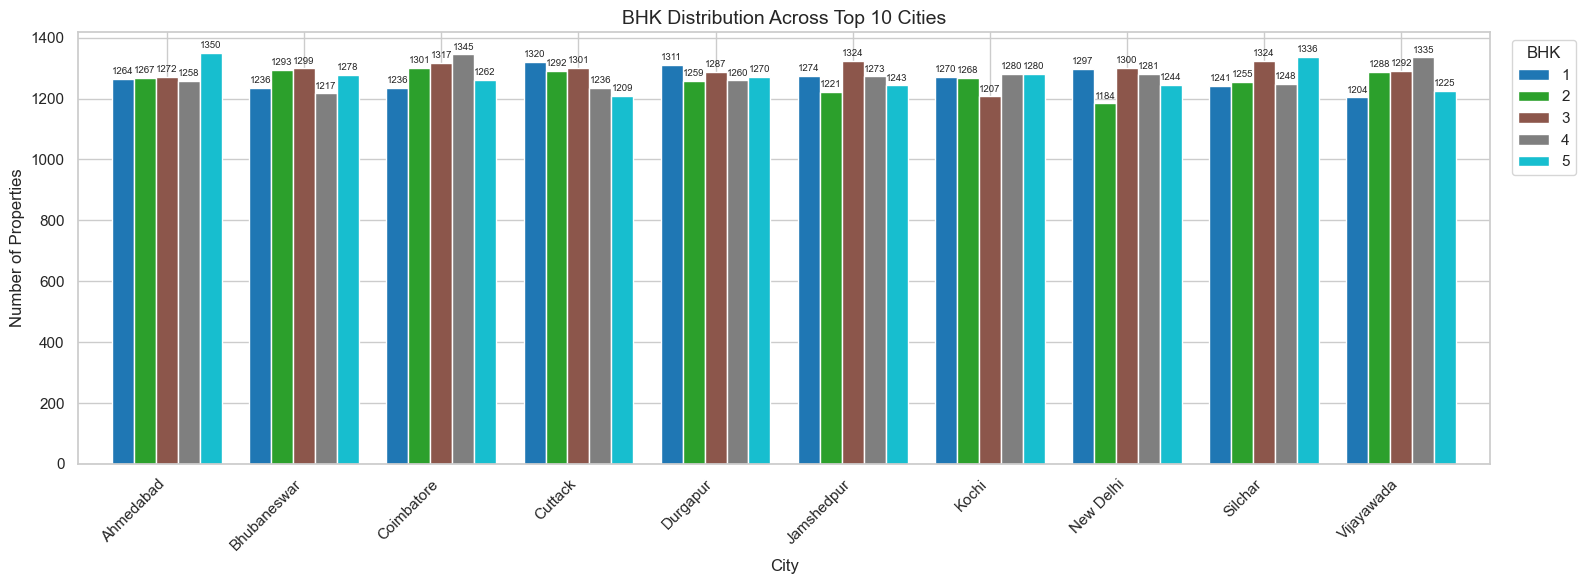

BHK
1    50196
2    49815
3    50067
4    49788
5    50134
Name: count, dtype: int64


In [10]:
# Q9: BHK Distribution across Top 10 Cities
top10_cities = df['City'].value_counts().head(10).index
df_top10 = df[df['City'].isin(top10_cities)]

fig, ax = plt.subplots(figsize=(16, 6))

bhk_city = df_top10.groupby(['City', 'BHK']).size().unstack(fill_value=0)
bhk_city.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.8)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=7, padding=2)

ax.set_title('BHK Distribution Across Top 10 Cities', fontsize=14)
ax.set_xlabel('City')
ax.set_ylabel('Number of Properties')
ax.legend(title='BHK', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df['BHK'].value_counts().sort_index())

### Q9 Insight: BHK Distribution Across Cities

- BHK distribution is **almost perfectly equal** across all top 10 cities — each BHK type (1–5) has roughly 1,200–1,350 properties per city
- At the dataset level, all 5 BHK types are nearly identical — 1BHK (50,196), 2BHK (49,815), 3BHK (50,067), 4BHK (49,788), 5BHK (50,134)
- In real markets, **2BHK and 3BHK dominate** most Indian cities — 1BHK is common in Mumbai while 4BHK+ is rare and premium
- No city shows a preference for any particular BHK type — confirming uniform synthetic generation
- **So what:** BHK will still be a useful feature in our model as it represents property size category — but it won't vary meaningfully by city in this dataset

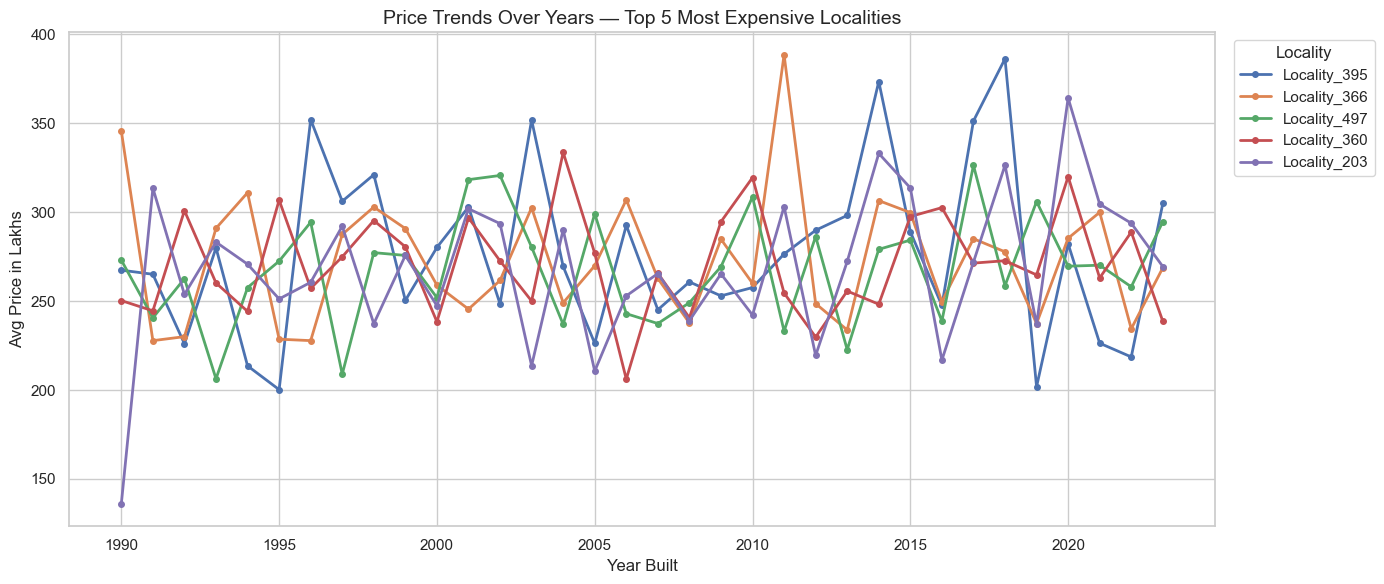

Top 5 most expensive localities (avg price):
Locality
Locality_395    275.425987
Locality_366    273.411996
Locality_497    269.995540
Locality_360    269.806792
Locality_203    269.033716
Name: Price_in_Lakhs, dtype: float64


In [11]:
# Q10: Price trends for Top 5 most expensive localities
top5_localities = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5).index
df_top5 = df[df['Locality'].isin(top5_localities)]

fig, ax = plt.subplots(figsize=(14, 6))

for locality in top5_localities:
    loc_data = df_top5[df_top5['Locality'] == locality].groupby('Year_Built')['Price_in_Lakhs'].mean()
    ax.plot(loc_data.index, loc_data.values, marker='o', linewidth=2, label=locality, markersize=4)

ax.set_title('Price Trends Over Years — Top 5 Most Expensive Localities', fontsize=14)
ax.set_xlabel('Year Built')
ax.set_ylabel('Avg Price in Lakhs')
ax.legend(title='Locality', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Top 5 most expensive localities (avg price):")
print(df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head())

### Q10 Insight: Price Trends for Top 5 Most Expensive Localities

- The top 5 localities by average price are **Locality_395 (₹275.4L), Locality_366 (₹273.4L), Locality_497 (₹270.0L), Locality_360 (₹269.8L) and Locality_203 (₹269.0L)**
- All 5 localities show **highly volatile, random price movements** across years (1990–2024) with no consistent upward trend
- In real markets, prime localities show **steady appreciation** over decades — the random zigzag pattern here confirms synthetic data
- The gap between the top and 5th locality is only **₹6.4 Lakhs** — very narrow spread
- **So what:** Year_Built has no meaningful relationship with price in this dataset — locality-level price signals are weak and noisy, reinforcing that our model will need to combine multiple features to generate useful predictions

## Section 3: Feature Relationship & Correlation (Q11–Q15)

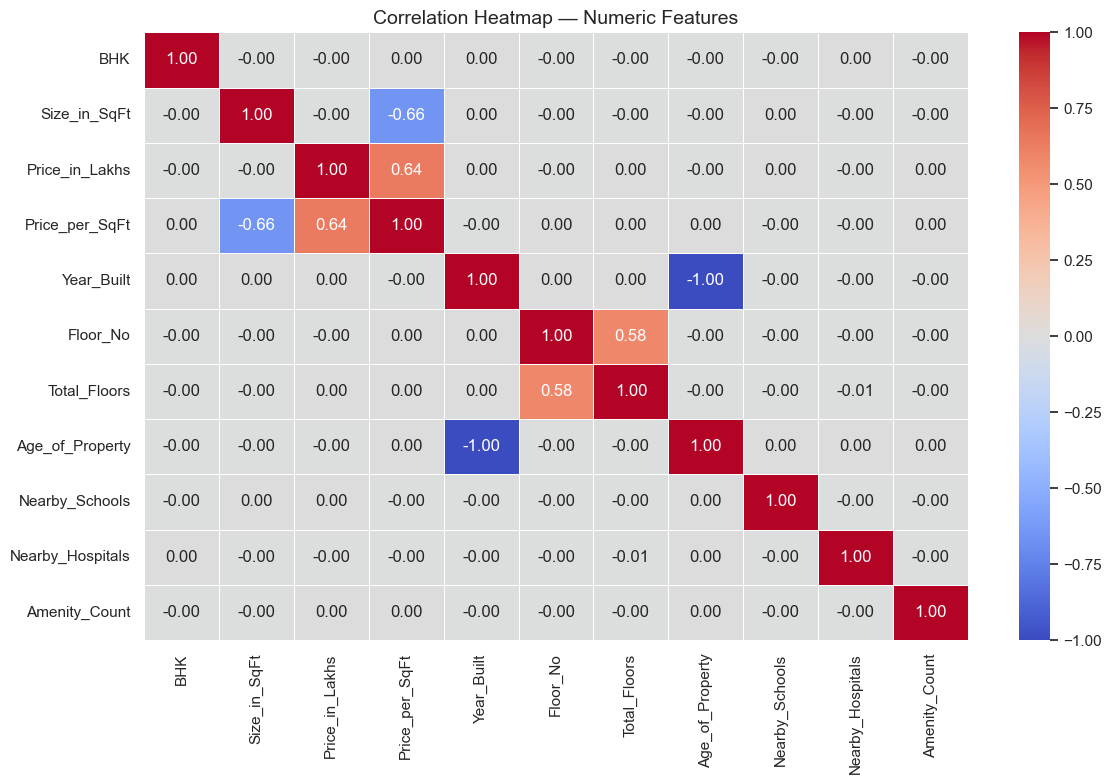

Top correlations with Price_in_Lakhs:
Price_in_Lakhs      1.000000
Price_per_SqFt      0.635193
Year_Built          0.002714
Total_Floors        0.001283
Amenity_Count       0.001029
Nearby_Schools      0.000155
Floor_No           -0.000850
BHK                -0.000980
Size_in_SqFt       -0.002529
Age_of_Property    -0.002714
Nearby_Hospitals   -0.002769
Name: Price_in_Lakhs, dtype: float64


In [12]:
# Q11: Correlation heatmap of numeric features
fig, ax = plt.subplots(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with Price
print("Top correlations with Price_in_Lakhs:")
print(corr_matrix['Price_in_Lakhs'].sort_values(ascending=False))

### Q11 Insight: Correlation Between Numeric Features

- **Price_per_SqFt and Price_in_Lakhs** have the strongest positive correlation at **0.64** — the only meaningful relationship in the dataset
- **Size_in_SqFt and Price_per_SqFt** show a strong negative correlation of **-0.66** — larger properties have lower price per SqFt, which makes mathematical sense (same price spread over more area)
- **Year_Built and Age_of_Property** are perfectly negatively correlated at **-1.00** — expected since Age = Current Year - Year_Built (one is derived from the other)
- **Floor_No and Total_Floors** show a moderate positive correlation of **0.58** — after our Phase 1 fix of capping Floor_No at Total_Floors
- All other feature pairs are essentially **0.00** — confirming independent random generation
- **So what:** Price_per_SqFt is our strongest numeric predictor for Price_in_Lakhs — we should drop either Year_Built or Age_of_Property before modeling to avoid multicollinearity

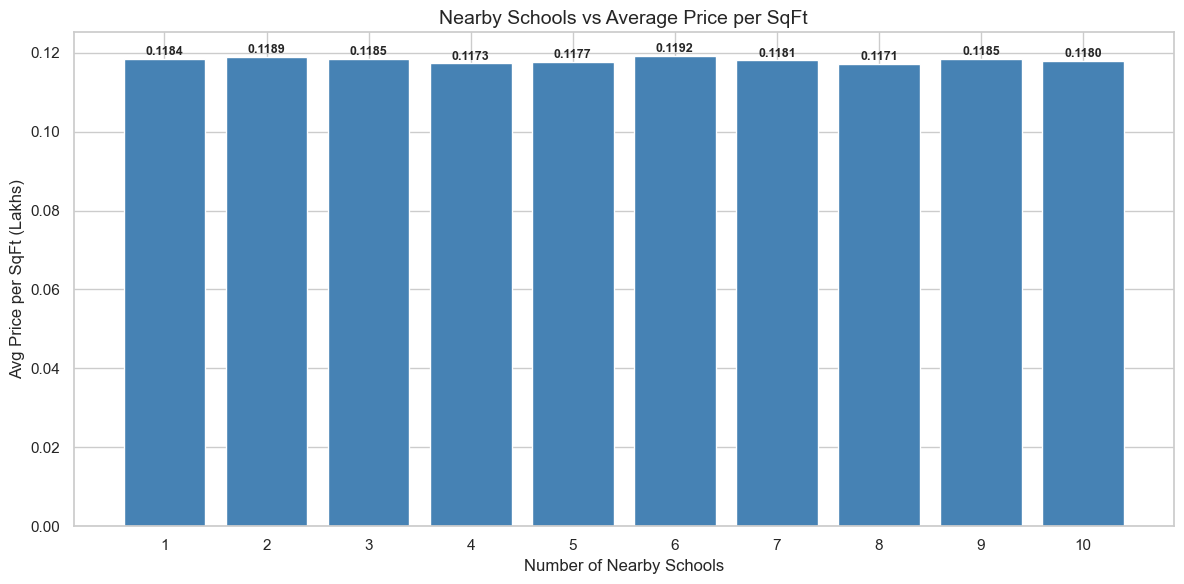

Correlation between Nearby_Schools and Price_per_SqFt: -0.0019


In [13]:
# Q12: Nearby Schools vs Price per SqFt
fig, ax = plt.subplots(figsize=(12, 6))

avg_schools = df.groupby('Nearby_Schools')['Price_per_SqFt'].mean()

bars = ax.bar(avg_schools.index, avg_schools.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, avg_schools.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Nearby Schools vs Average Price per SqFt', fontsize=14)
ax.set_xlabel('Number of Nearby Schools')
ax.set_ylabel('Avg Price per SqFt (Lakhs)')
ax.set_xticks(avg_schools.index)
plt.tight_layout()
plt.show()

corr = df['Nearby_Schools'].corr(df['Price_per_SqFt'])
print(f"Correlation between Nearby_Schools and Price_per_SqFt: {corr:.4f}")

### Q12 Insight: Nearby Schools vs Price per SqFt

- Average Price per SqFt stays **flat across all school counts** (1–10) — ranging narrowly between 0.1171 and 0.1192
- Correlation is essentially **zero (-0.0019)** — nearby schools have no influence on price per SqFt
- In real markets, **school proximity is a premium factor** — properties near top schools command 10–20% higher prices in cities like Bangalore, Mumbai and Pune
- The flat pattern confirms synthetic data where school count was assigned independently of price
- **So what:** Nearby_Schools is likely a weak feature for our model — but we'll retain it and let the model decide its importance via feature importance scores

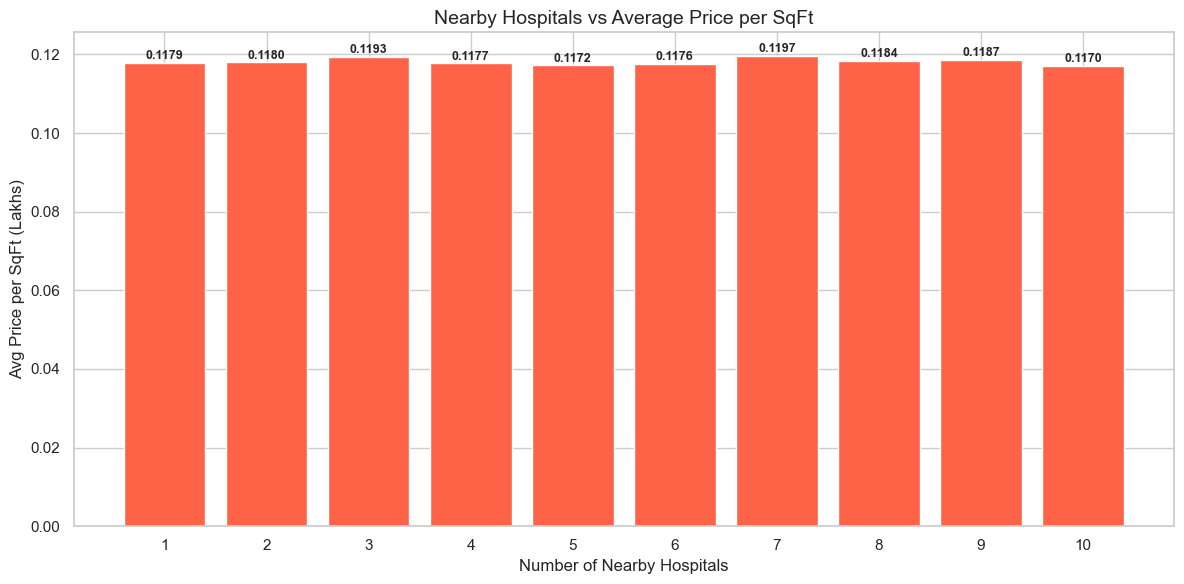

Correlation between Nearby_Hospitals and Price_per_SqFt: -0.0004


In [14]:
# Q13: Nearby Hospitals vs Price per SqFt
fig, ax = plt.subplots(figsize=(12, 6))

avg_hospitals = df.groupby('Nearby_Hospitals')['Price_per_SqFt'].mean()

bars = ax.bar(avg_hospitals.index, avg_hospitals.values, color='tomato', edgecolor='white')

for bar, val in zip(bars, avg_hospitals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Nearby Hospitals vs Average Price per SqFt', fontsize=14)
ax.set_xlabel('Number of Nearby Hospitals')
ax.set_ylabel('Avg Price per SqFt (Lakhs)')
ax.set_xticks(avg_hospitals.index)
plt.tight_layout()
plt.show()

corr = df['Nearby_Hospitals'].corr(df['Price_per_SqFt'])
print(f"Correlation between Nearby_Hospitals and Price_per_SqFt: {corr:.4f}")

### Q13 Insight: Nearby Hospitals vs Price per SqFt

- Same flat pattern as schools — avg Price per SqFt stays between **0.1170 and 0.1197** across all hospital counts (1–10)
- Correlation is virtually **zero (-0.0004)** — hospitals have no influence on price per SqFt
- In real markets, **hospital proximity has mixed effects** — premium hospitals in upscale areas boost prices while general hospitals in dense urban areas can have neutral or negative effects
- Both Nearby_Schools and Nearby_Hospitals show identical behavior — independently generated from price in this dataset
- **So what:** Nearby_Hospitals is also likely a weak standalone predictor — however combining it with Nearby_Schools into a composite "Infrastructure Score" feature during Phase 3 may add more signal for our model

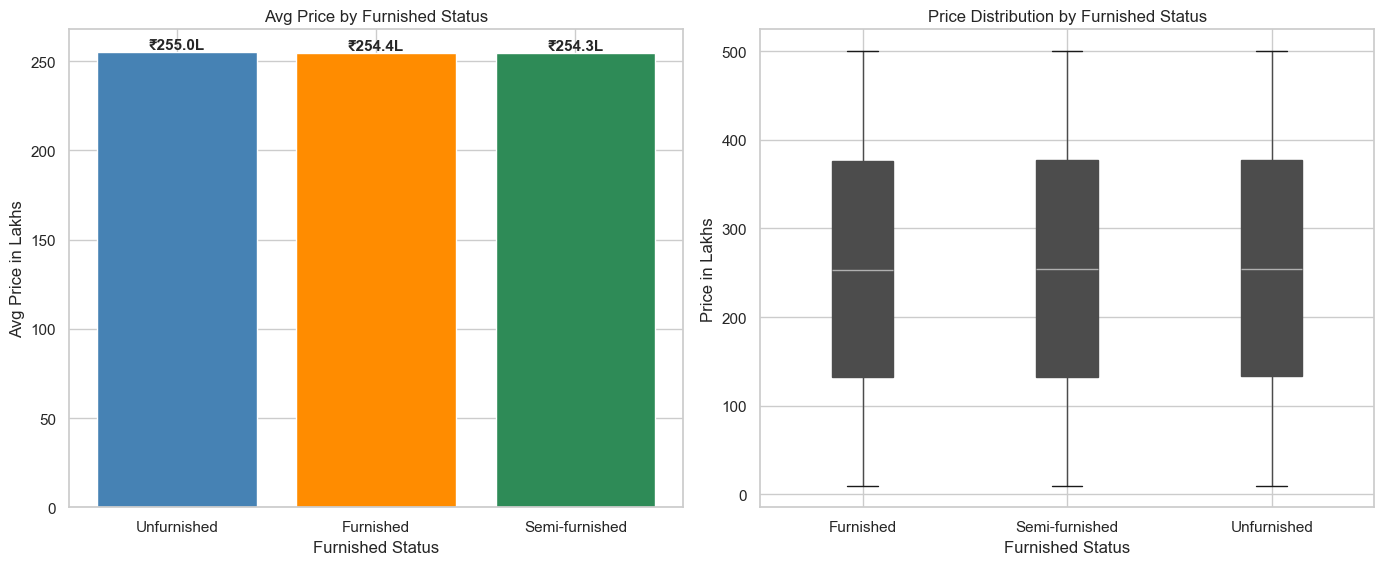

Furnished_Status
Unfurnished       254.979752
Furnished         254.445550
Semi-furnished    254.334836
Name: Price_in_Lakhs, dtype: float64


In [15]:
# Q14: Price by Furnished Status
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - avg price
avg_furnished = df.groupby('Furnished_Status')['Price_in_Lakhs'].mean().sort_values(ascending=False)
bars = axes[0].bar(avg_furnished.index, avg_furnished.values,
                   color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
for bar, val in zip(bars, avg_furnished.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'₹{val:.1f}L', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Avg Price by Furnished Status')
axes[0].set_xlabel('Furnished Status')
axes[0].set_ylabel('Avg Price in Lakhs')

# Boxplot
df.boxplot(column='Price_in_Lakhs', by='Furnished_Status', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Price Distribution by Furnished Status')
axes[1].set_xlabel('Furnished Status')
axes[1].set_ylabel('Price in Lakhs')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(avg_furnished)

### Q14 Insight: Price by Furnished Status

- All three furnished categories show **nearly identical average prices** — Unfurnished (₹255.0L), Furnished (₹254.4L) and Semi-furnished (₹254.3L)
- The difference between highest and lowest is just **₹0.7 Lakhs** — statistically negligible
- Interestingly, **Unfurnished properties are slightly more expensive** — the opposite of real market behavior where fully furnished properties command a 10–15% premium
- The boxplots confirm **identical price distributions** across all three categories — same spread, same median, same range
- **So what:** Furnished_Status is a weak price predictor in this dataset — but it remains a relevant feature for the classification model since buyers factor furnishing into investment decisions

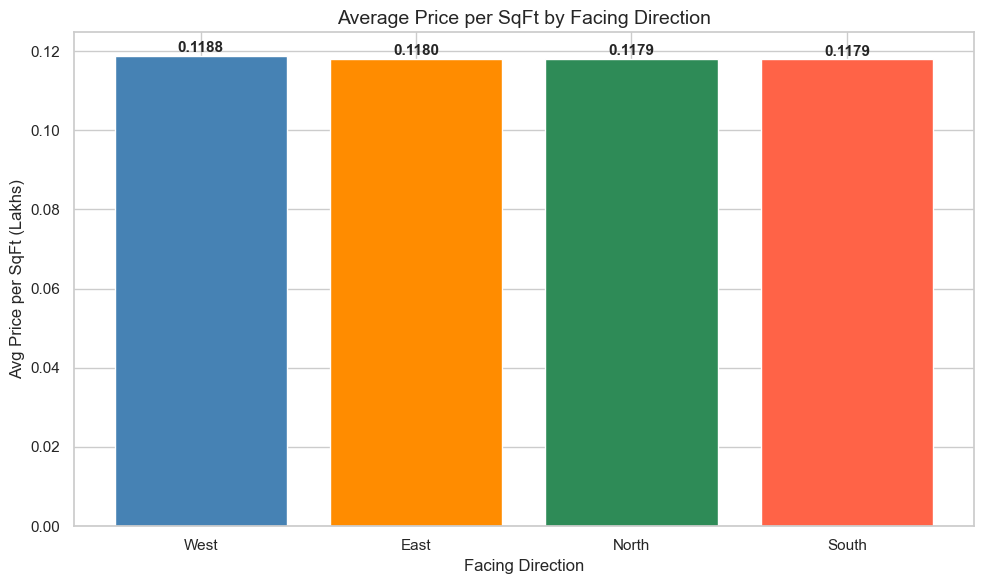

Facing
West     0.118784
East     0.117974
North    0.117942
South    0.117904
Name: Price_per_SqFt, dtype: float64

Property count by facing direction:
Facing
West     62757
North    62637
South    62337
East     62269
Name: count, dtype: int64


In [16]:
# Q15: Price per SqFt by Facing Direction
fig, ax = plt.subplots(figsize=(10, 6))

avg_facing = df.groupby('Facing')['Price_per_SqFt'].mean().sort_values(ascending=False)

bars = ax.bar(avg_facing.index, avg_facing.values,
              color=['steelblue', 'darkorange', 'seagreen', 'tomato'], edgecolor='white')

for bar, val in zip(bars, avg_facing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Price per SqFt by Facing Direction', fontsize=14)
ax.set_xlabel('Facing Direction')
ax.set_ylabel('Avg Price per SqFt (Lakhs)')
plt.tight_layout()
plt.show()

print(avg_facing)
print(f"\nProperty count by facing direction:")
print(df['Facing'].value_counts())

### Q15 Insight: Price per SqFt by Facing Direction

- All four facing directions show **virtually identical Price per SqFt** — West (0.1188), East (0.1180), North (0.1179), South (0.1179)
- The spread across all directions is just **0.0009 Lakhs/SqFt** — negligible
- Properties are also **evenly distributed** across all directions — West (62,757), North (62,637), South (62,337), East (62,269)
- In real markets, **North and East facing properties** command a premium in Indian real estate due to Vastu preferences — typically 5–10% higher than South or West facing
- **So what:** Facing direction is a weak predictor in this dataset — it will likely have very low feature importance in our model, but we'll retain it for completeness

## Section 4: Investment, Amenities & Ownership Analysis (Q16–Q20)

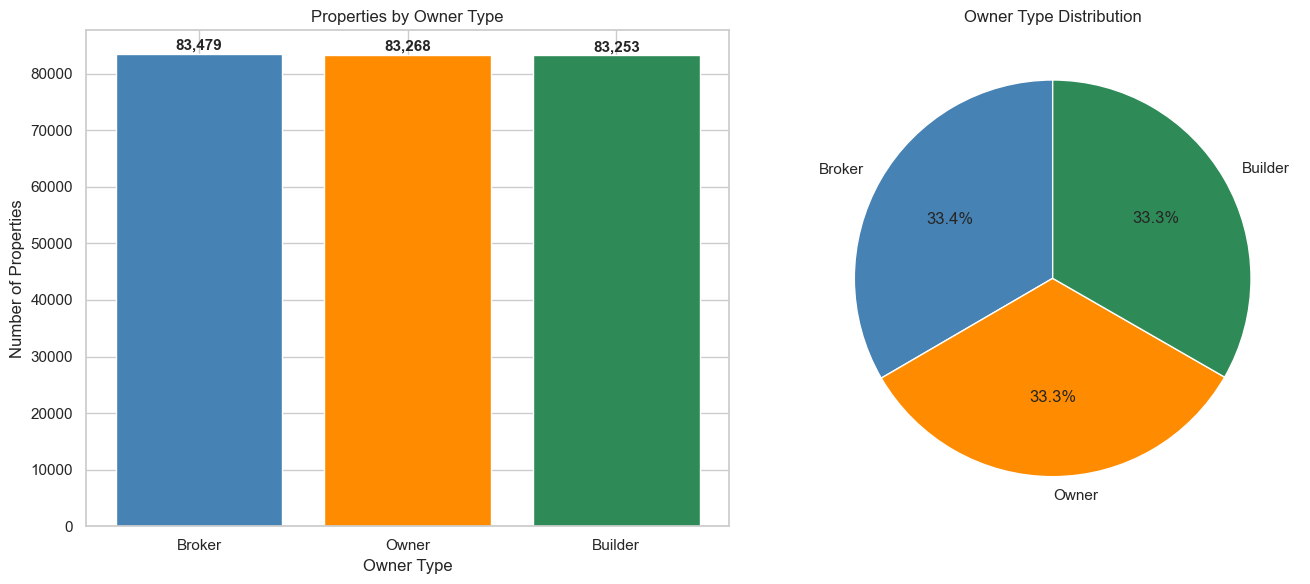

Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64


In [17]:
# Q16: Properties by Owner Type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

owner_counts = df['Owner_Type'].value_counts()

# Bar chart
bars = axes[0].bar(owner_counts.index, owner_counts.values,
                   color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
for bar, val in zip(bars, owner_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Properties by Owner Type')
axes[0].set_xlabel('Owner Type')
axes[0].set_ylabel('Number of Properties')

# Pie chart
axes[1].pie(owner_counts.values, labels=owner_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'darkorange', 'seagreen'],
            startangle=90)
axes[1].set_title('Owner Type Distribution')

plt.tight_layout()
plt.show()

print(owner_counts)

### Q16 Insight: Properties by Owner Type

- Properties are **perfectly evenly split** across all three owner types — Broker (83,479 / 33.4%), Owner (83,268 / 33.3%), Builder (83,253 / 33.3%)
- The difference between the largest and smallest group is just **226 properties** out of 250,000 — a perfectly balanced synthetic split
- In real markets, **Builders dominate new construction listings** while individual Owners are more common in resale markets — Brokers act as intermediaries for both
- Owner-listed properties typically offer better negotiation potential while Builder properties come with standardized pricing
- **So what:** Owner_Type is an evenly distributed categorical feature — it will be encoded and included in our model but is unlikely to be a strong predictor given the uniform distribution

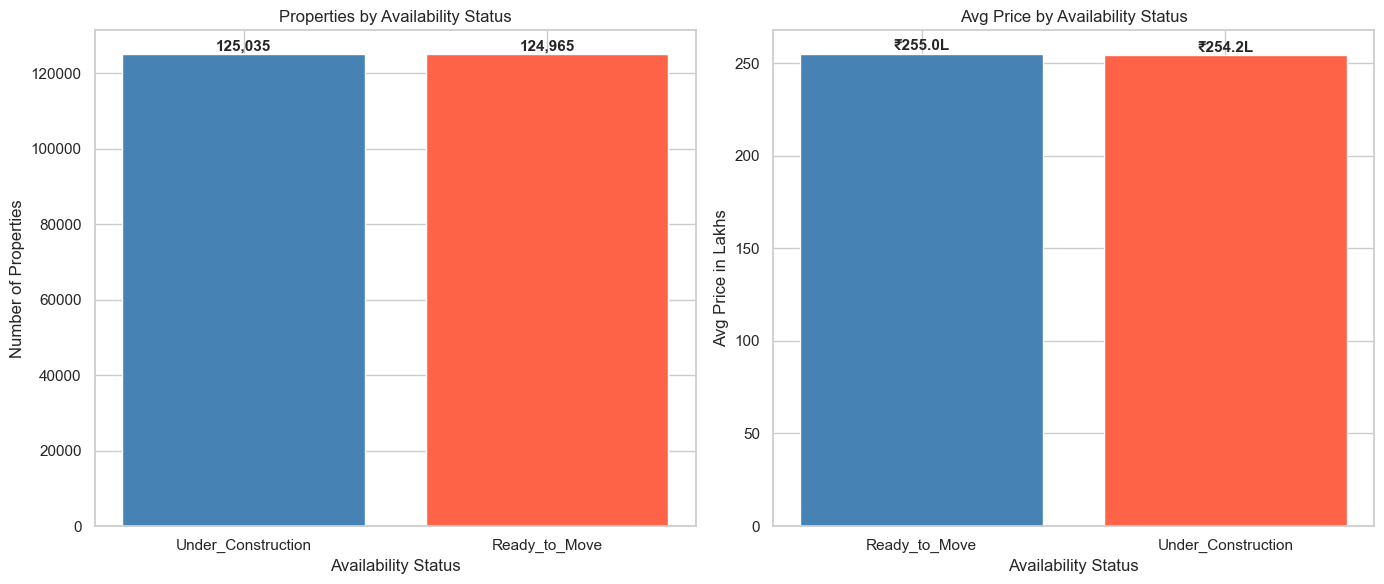

Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64

Avg price by status:
Availability_Status
Ready_to_Move         254.983787
Under_Construction    254.190144
Name: Price_in_Lakhs, dtype: float64


In [18]:
# Q17: Properties by Availability Status
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

status_counts = df['Availability_Status'].value_counts()

# Bar chart
bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Properties by Availability Status')
axes[0].set_xlabel('Availability Status')
axes[0].set_ylabel('Number of Properties')

# Avg price by status
avg_price_status = df.groupby('Availability_Status')['Price_in_Lakhs'].mean()
bars2 = axes[1].bar(avg_price_status.index, avg_price_status.values,
                    color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars2, avg_price_status.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'₹{val:.1f}L', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Avg Price by Availability Status')
axes[1].set_xlabel('Availability Status')
axes[1].set_ylabel('Avg Price in Lakhs')

plt.tight_layout()
plt.show()

print(status_counts)
print(f"\nAvg price by status:")
print(avg_price_status)

### Q17 Insight: Properties by Availability Status

- Properties are **almost perfectly split** between Under Construction (125,035 / 50.01%) and Ready to Move (124,965 / 49.99%)
- **Ready to Move properties are slightly more expensive** — ₹255.0L vs ₹254.2L for Under Construction — a difference of just ₹0.8 Lakhs
- In real markets, **Under Construction properties are priced lower** (10–20% discount) as buyers take on completion risk — Ready to Move commands a premium for immediacy and certainty
- The near-equal split and negligible price difference again confirms uniform synthetic generation
- **So what:** Availability_Status is an important feature for our **classification model** — in real investing, Ready to Move properties are generally safer and preferred for immediate rental income generation

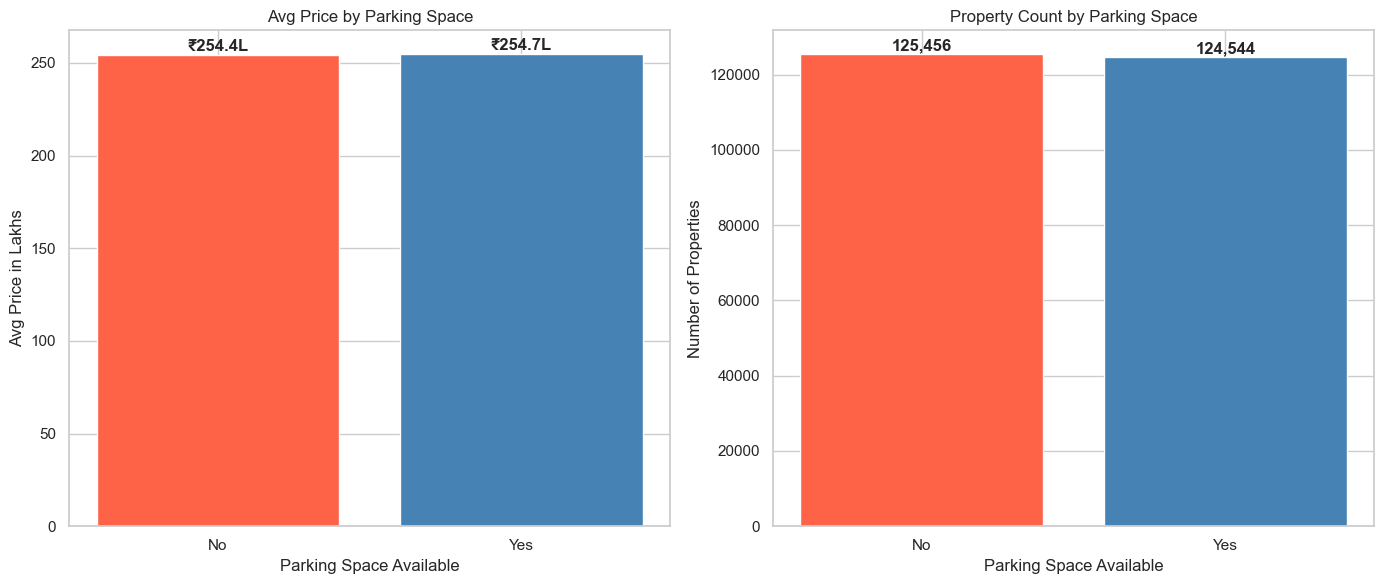

Parking_Space
No     254.429369
Yes    254.745492
Name: Price_in_Lakhs, dtype: float64

Property count:
Parking_Space
No     125456
Yes    124544
Name: count, dtype: int64


In [19]:
# Q18: Parking Space vs Property Price
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg price by parking
avg_parking = df.groupby('Parking_Space')['Price_in_Lakhs'].mean()
bars = axes[0].bar(avg_parking.index, avg_parking.values,
                   color=['tomato', 'steelblue'], edgecolor='white')
for bar, val in zip(bars, avg_parking.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'₹{val:.1f}L', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Avg Price by Parking Space')
axes[0].set_xlabel('Parking Space Available')
axes[0].set_ylabel('Avg Price in Lakhs')

# Count by parking
parking_counts = df['Parking_Space'].value_counts()
bars2 = axes[1].bar(parking_counts.index, parking_counts.values,
                    color=['tomato', 'steelblue'], edgecolor='white')
for bar, val in zip(bars2, parking_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Property Count by Parking Space')
axes[1].set_xlabel('Parking Space Available')
axes[1].set_ylabel('Number of Properties')

plt.tight_layout()
plt.show()

print(avg_parking)
print(f"\nProperty count:")
print(parking_counts)

### Q18 Insight: Parking Space vs Property Price

- Properties with parking (₹254.7L) are **marginally more expensive** than those without (₹254.4L) — a difference of just ₹0.3 Lakhs
- The dataset is **evenly split** — No Parking (125,456) vs Parking (124,544) — a difference of only 912 properties
- In real markets, **parking is a significant value-add** — especially in metro cities like Mumbai, Bangalore and Delhi where parking can add ₹5–15 Lakhs to property value
- The near-zero price difference confirms parking was assigned independently of price in this synthetic dataset
- **So what:** Parking_Space will be encoded as a binary feature (0/1) in our model — while its standalone price signal is weak here, it is a strong real-world investment consideration and will be retained for the classification model

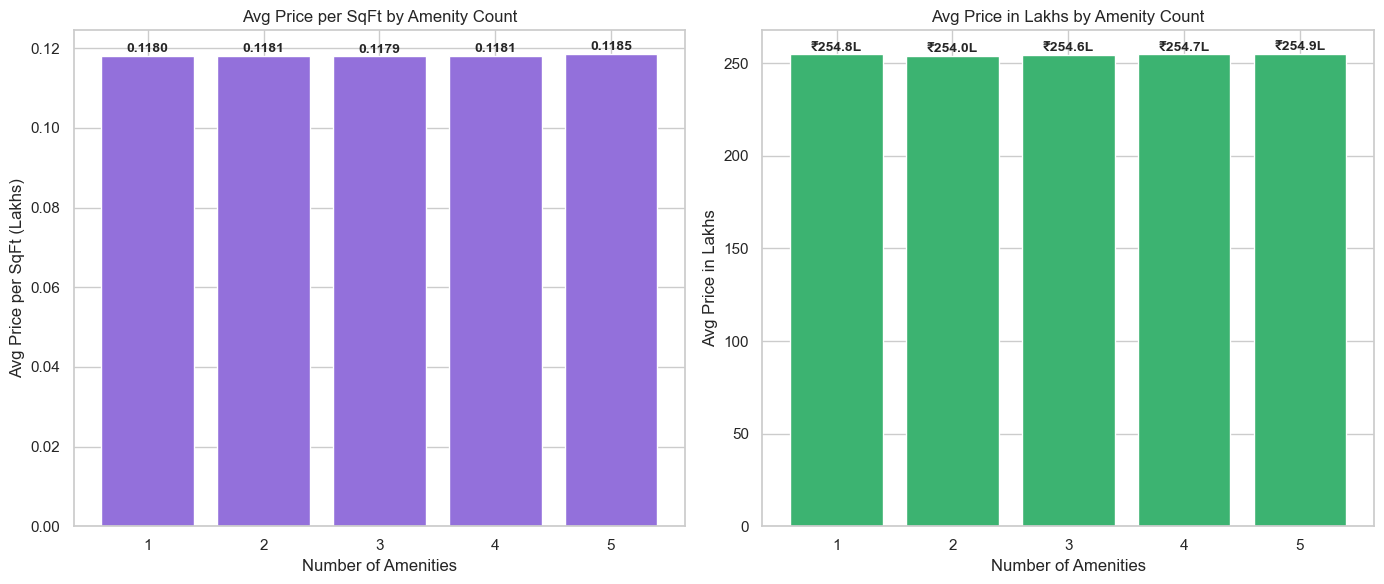

Correlation between Amenity_Count and Price_per_SqFt: 0.0015

Avg Price per SqFt by Amenity Count:
Amenity_Count
1    0.118037
2    0.118135
3    0.117938
4    0.118103
5    0.118548
Name: Price_per_SqFt, dtype: float64


In [20]:
# Q19: Amenity Count vs Price per SqFt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg price per sqft by amenity count
avg_amenity = df.groupby('Amenity_Count')['Price_per_SqFt'].mean()
bars = axes[0].bar(avg_amenity.index, avg_amenity.values,
                   color='mediumpurple', edgecolor='white')
for bar, val in zip(bars, avg_amenity.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Avg Price per SqFt by Amenity Count')
axes[0].set_xlabel('Number of Amenities')
axes[0].set_ylabel('Avg Price per SqFt (Lakhs)')
axes[0].set_xticks(avg_amenity.index)

# Avg price in lakhs by amenity count
avg_amenity_price = df.groupby('Amenity_Count')['Price_in_Lakhs'].mean()
bars2 = axes[1].bar(avg_amenity_price.index, avg_amenity_price.values,
                    color='mediumseagreen', edgecolor='white')
for bar, val in zip(bars2, avg_amenity_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'₹{val:.1f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Avg Price in Lakhs by Amenity Count')
axes[1].set_xlabel('Number of Amenities')
axes[1].set_ylabel('Avg Price in Lakhs')
axes[1].set_xticks(avg_amenity_price.index)

plt.tight_layout()
plt.show()

corr = df['Amenity_Count'].corr(df['Price_per_SqFt'])
print(f"Correlation between Amenity_Count and Price_per_SqFt: {corr:.4f}")
print(f"\nAvg Price per SqFt by Amenity Count:")
print(avg_amenity)

### Q19 Insight: Amenities vs Price per SqFt

- Amenity count shows **no meaningful impact** on either Price per SqFt or Price in Lakhs — all 5 amenity levels are virtually flat
- Price per SqFt ranges from just 0.1179 (3 amenities) to 0.1185 (5 amenities) — a difference of **0.0006 Lakhs**
- Price in Lakhs ranges from ₹254.0L (2 amenities) to ₹254.9L (5 amenities) — a spread of just **₹0.9 Lakhs**
- Correlation between Amenity_Count and Price_per_SqFt is near zero at **0.0015**
- In real markets, **premium amenities (Pool, Gym, Clubhouse) add 5–15% to property value** — especially in gated communities in Bangalore, Pune and Hyderabad
- **So what:** While Amenity_Count is weak as a standalone predictor, it represents a real-world investment signal — properties with more amenities attract better tenants and higher rental yields, making it valuable for our classification model

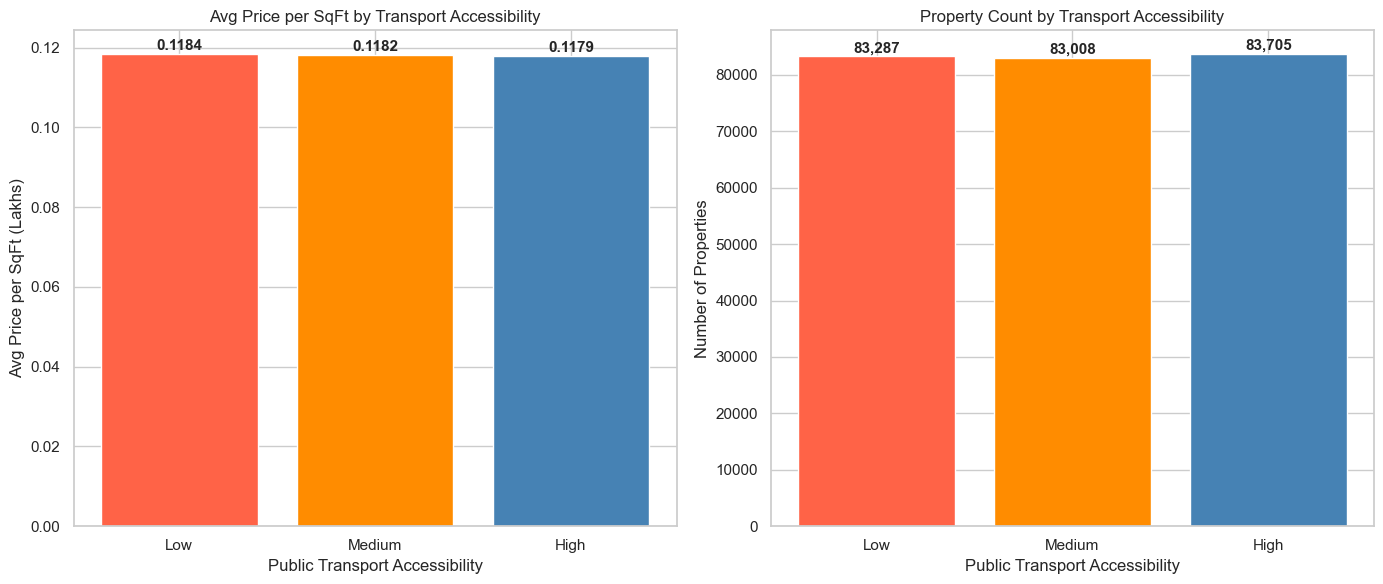

Avg Price per SqFt by Transport Accessibility:
Public_Transport_Accessibility
Low       0.118429
Medium    0.118171
High      0.117858
Name: Price_per_SqFt, dtype: float64

Property count:
Public_Transport_Accessibility
Low       83287
Medium    83008
High      83705
Name: count, dtype: int64


In [21]:
# Q20: Public Transport Accessibility vs Price per SqFt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avg price per sqft by transport accessibility
avg_transport = df.groupby('Public_Transport_Accessibility')['Price_per_SqFt'].mean()
order = ['Low', 'Medium', 'High']
avg_transport = avg_transport.reindex(order)

bars = axes[0].bar(avg_transport.index, avg_transport.values,
                   color=['tomato', 'darkorange', 'steelblue'], edgecolor='white')
for bar, val in zip(bars, avg_transport.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Avg Price per SqFt by Transport Accessibility')
axes[0].set_xlabel('Public Transport Accessibility')
axes[0].set_ylabel('Avg Price per SqFt (Lakhs)')

# Property count by transport
transport_counts = df['Public_Transport_Accessibility'].value_counts().reindex(order)
bars2 = axes[1].bar(transport_counts.index, transport_counts.values,
                    color=['tomato', 'darkorange', 'steelblue'], edgecolor='white')
for bar, val in zip(bars2, transport_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Property Count by Transport Accessibility')
axes[1].set_xlabel('Public Transport Accessibility')
axes[1].set_ylabel('Number of Properties')

plt.tight_layout()
plt.show()

print("Avg Price per SqFt by Transport Accessibility:")
print(avg_transport)
print(f"\nProperty count:")
print(transport_counts)

### Q20 Insight: Public Transport Accessibility vs Price per SqFt

- Price per SqFt shows **no meaningful variation** across transport levels — Low (0.1184), Medium (0.1182), High (0.1179)
- Surprisingly, **Low accessibility properties are marginally more expensive** than High accessibility ones — the opposite of real market behavior
- Properties are **evenly distributed** across all three levels — Low (83,287), Medium (83,008), High (83,705)
- In real markets, **metro connectivity and transport access are among the strongest price drivers** — properties near metro stations in Bangalore, Mumbai and Delhi command 15–25% premiums
- **So what:** Public_Transport_Accessibility will be encoded as an ordinal feature (Low=1, Medium=2, High=3) in Phase 3 — while its price signal is weak here, it is a critical real-world investment factor and should remain in our classification model

## Phase 2 Summary — EDA Findings

### Key Takeaways

| # | Finding | Implication for Modeling |
|---|---------|--------------------------|
| 1 | All numeric features are uniformly distributed | No natural skew to correct before modeling |
| 2 | Price_per_SqFt is the only strong numeric predictor (r=0.64) | Include as a key feature in both models |
| 3 | Year_Built and Age_of_Property are perfectly correlated (-1.0) | Drop one before modeling to avoid multicollinearity |
| 4 | Floor_No and Total_Floors are moderately correlated (0.58) | Monitor for multicollinearity |
| 5 | All categorical features show uniform distribution | Encoding will not create class imbalance |
| 6 | Location features (State, City, Locality) show minimal price variation | Combined features will be more powerful than individual ones |
| 7 | Dataset is synthetically generated | Model will learn patterns from feature combinations, not real-world signals |

### Ready for Phase 3: Feature Engineering